In [31]:
import json
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

import seaborn as sns
sns.set_style('whitegrid')

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
with open("logins.json", 'r') as f:
    data = json.load(f)

In [3]:
df = pd.DataFrame(data)

In [4]:
df['login_time'] = pd.to_datetime(df['login_time'])

In [5]:
df.dtypes

login_time    datetime64[us]
dtype: object

In [6]:
df.set_index("login_time",inplace=True)
df['count'] = 1
df2 = df.resample('15min').count()


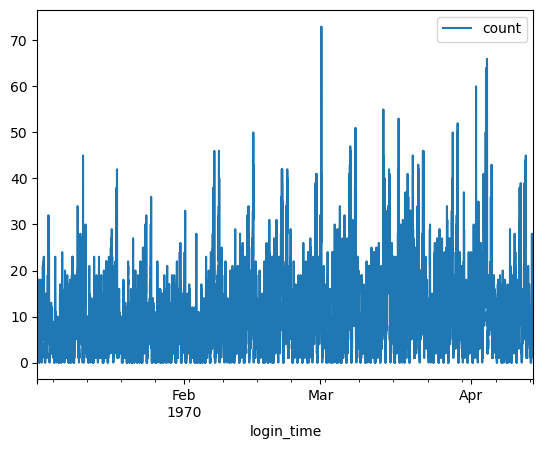

In [7]:
df2.plot(kind='line')
plt.show()

In [8]:
df2['day_of_week'] = df2.reset_index()['login_time'].dt.day_name().values

In [9]:
df_days = df2.groupby('day_of_week').apply(np.sum)

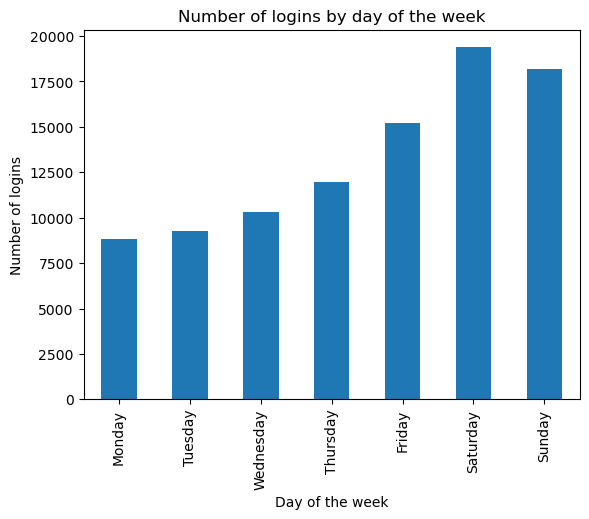

In [11]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df_days.reindex(order).plot(kind='bar')
plt.title('Number of logins by day of the week')
plt.xlabel('Day of the week')
plt.ylabel('Number of logins')
plt.show()

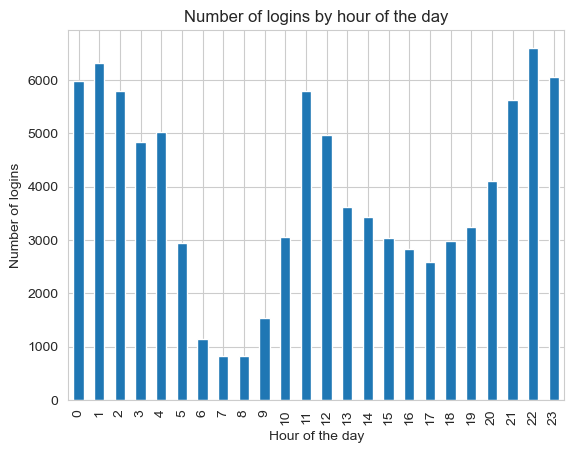

In [16]:
df2['hour_of_day'] = df2.reset_index()['login_time'].dt.hour.values
df_hours = df2.groupby('hour_of_day')['count'].apply(np.sum)
df_hours.plot(kind='bar')
plt.title('Number of logins by hour of the day')
plt.xlabel('Hour of the day')
plt.ylabel('Number of logins')
plt.show()

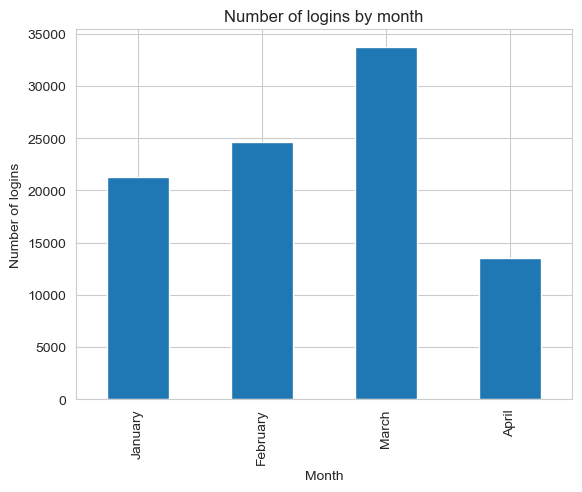

In [18]:
df2['month'] = df2.reset_index()['login_time'].dt.month_name().values
df_months = df2.groupby('month')['count'].apply(np.sum)
order = ['January', 'February', 'March', 'April']
df_months.reindex(order).plot(kind='bar')
plt.title('Number of logins by month')
plt.xlabel('Month')
plt.ylabel('Number of logins')
plt.show()

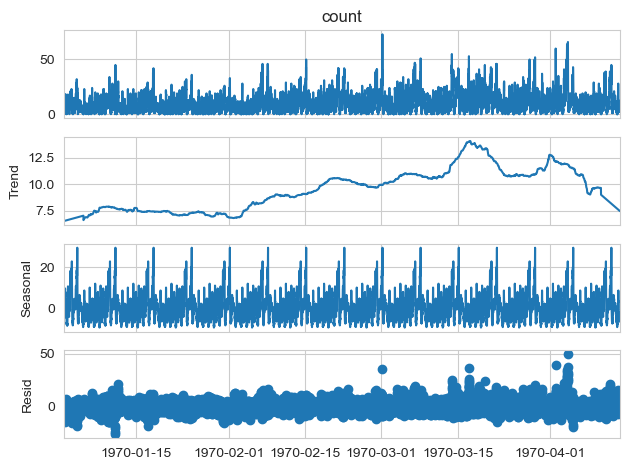

In [30]:
seasonal_decomposition = sm.tsa.seasonal_decompose(df2['count'], model='additive',period=7*24*4,extrapolate_trend='freq')
seasonal_decomposition.plot()

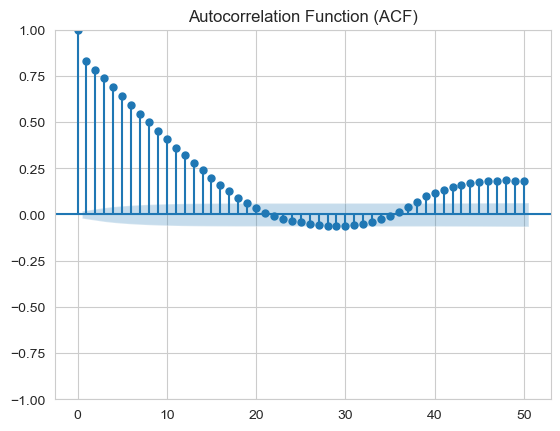

In [37]:
plot_acf(df2['count'].dropna(), lags=50)
plt.title('Autocorrelation Function (ACF)')
plt.show()

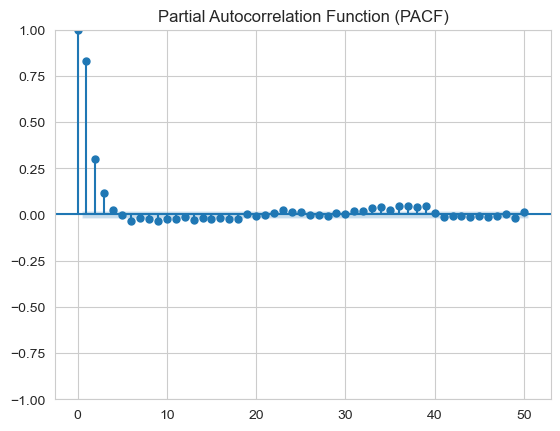

In [40]:
plot_pacf(df2['count'].dropna(), lags=50, method='ywm')
plt.title('Partial Autocorrelation Function (PACF)')
plt.show()